In [ ]:
import os
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from PIL import Image
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.layers import Flatten, Dense, Conv2D, MaxPooling2D, Dropout, Input, BatchNormalization
from tensorflow.keras.datasets import mnist

In [ ]:
D = os.system('kaggle kernels pull salehzeer/mnist-dataset')

In [ ]:
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [ ]:
 b    x_train = x_train.reshape(-1, 28, 28, 1) / 255.0
x_test = x_test.reshape(-1, 28, 28, 1) / 255.0

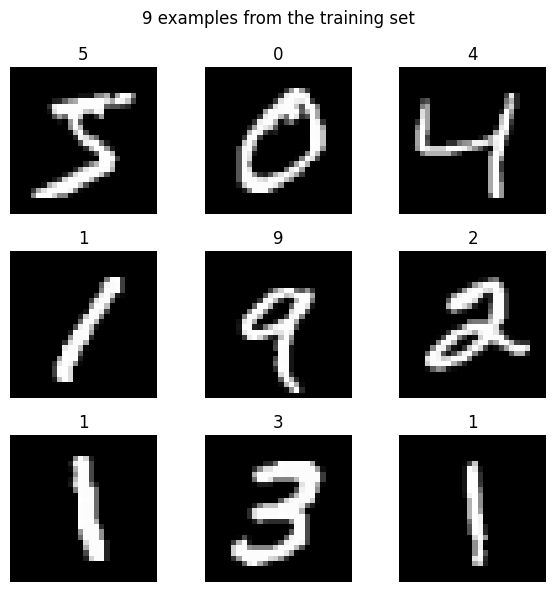

In [ ]:
class_names = [str(i) for i in range(10)]

plt.figure(figsize=(6, 6))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_train[i].squeeze(), cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.suptitle("9 examples from the training set")
plt.tight_layout()
plt.show()

In [ ]:
model = Sequential([
    Input(shape=(28, 28, 1)),

    Flatten(),

    Dense(1024, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),

    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),

    Dense(10, activation='softmax')
])

In [ ]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1024)           │       803,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,339,914 (5.11 MB)

 Trainable params: 1,336,842 (5.10 MB)

 Non-trainable params: 3,072 (12.00 KB)

In [ ]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
checkpoint = ModelCheckpoint(
    'best_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

history = model.fit(x_train, y_train,
                    epochs=100,
                    batch_size=64,
                    validation_split=0.2,
                    callbacks=[checkpoint])

Epoch 1/100
748/750 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8498 - loss: 0.5160
Epoch 1: val_accuracy improved from None to 0.96233, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9014 - loss: 0.3319 - val_accuracy: 0.9623 - val_loss: 0.1252
Epoch 2/100
737/750 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9431 - loss: 0.1832
Epoch 2: val_accuracy improved from 0.96233 to 0.97033, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9471 - loss: 0.1739 - val_accuracy: 0.9703 - val_loss: 0.1055
Epoch 3/100
739/750 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9537 - loss: 0.1454
Epoch 3: val_accuracy improved from 0.97033 to 0.97492, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9553 - loss: 0.1423 - val_accu

In [ ]:
test_loss, test_accuracy = model.evaluate(x_test,  y_test, verbose=2)
print(f"\nAccuracy: {test_accuracy * 100:.2f}%")

313/313 - 1s - 3ms/step - accuracy: 0.9861 - loss: 0.0644

Accuracy: 98.61%


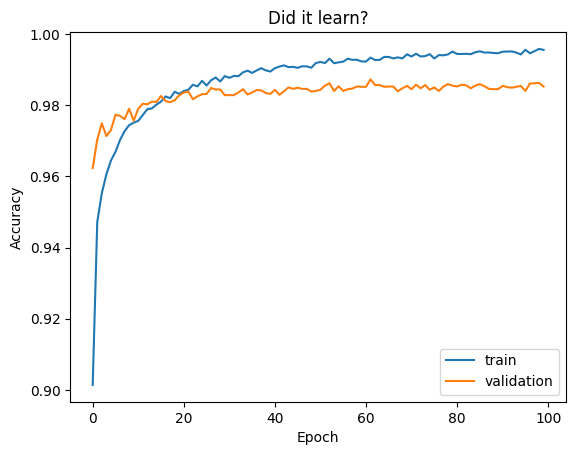

In [ ]:
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='validation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Did it learn?')
plt.legend()
plt.show()

In [ ]:
image_path = '/content/Screenshot 2026-07-28 172717.png'

# Check if file exists and load it directly
if os.path.exists(image_path):
    img = Image.open(image_path).convert('L') # Convert to grayscale
    img = img.resize((28, 28))

    # Convert image to numpy array and normalize
    img_array = np.array(img) / 255.0

    print(f"Image loaded from {image_path}. Shape: {img_array.shape}")

    # Add batch and channel dimensions for the model input
    processed_image = img_array.reshape(1, 28, 28, 1)

    # Predict using the trained model
    probabilities = model.predict(processed_image, verbose=0)[0]
    predicted_label = class_names[np.argmax(probabilities)]
    confidence = np.max(probabilities)

    # Plot results
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    ax1.imshow(img_array, cmap='gray')
    ax1.axis('off')
    ax1.set_title(f"Model Guess: {predicted_label} ({confidence:.0%})")

    ax2.barh(class_names, probabilities)
    ax2.set_xlim(0, 1)
    ax2.set_xlabel('Probability')
    ax2.set_title("Prediction Confidence")
    plt.tight_layout()
    plt.show()
else:
    print(f"Error: The file {image_path} was not found. Please ensure it is uploaded to the /content/ folder.")

Error: The file /content/Screenshot 2026-07-28 172717.png was not found. Please ensure it is uploaded to the /content/ folder.
